## The Gradient — Visualizing It as an Arrow

A **contour plot** is a top-down map of a surface: each ring (contour) connects
points of equal height, exactly like elevation lines on a hiking map. Rings
close together mean a steep slope; rings far apart mean gentle ground.

For $f(x, y) = x^2 + y^2$ (a bowl), the contours are circles centred on the
minimum at the origin — the innermost ring is the bottom.

### What the plot below shows

At a chosen point we draw the **gradient vector** $\nabla f = (2x, 2y)$ as an
arrow. Two things to watch for:

- **Direction:** the arrow points *away* from the centre — the direction of
  steepest **ascent** (most uphill). Its opposite (dashed) points back toward
  the minimum — the direction of steepest **descent**, which is the way gradient
  descent steps.
- **It's perpendicular to the contour.** The steepest way uphill is always at a
  right angle to the "equal-height" ring — a key geometric fact about gradients.

The arrow's **length** reflects the magnitude (steepness): points farther from
the minimum sit on tightly-packed contours and have longer arrows.

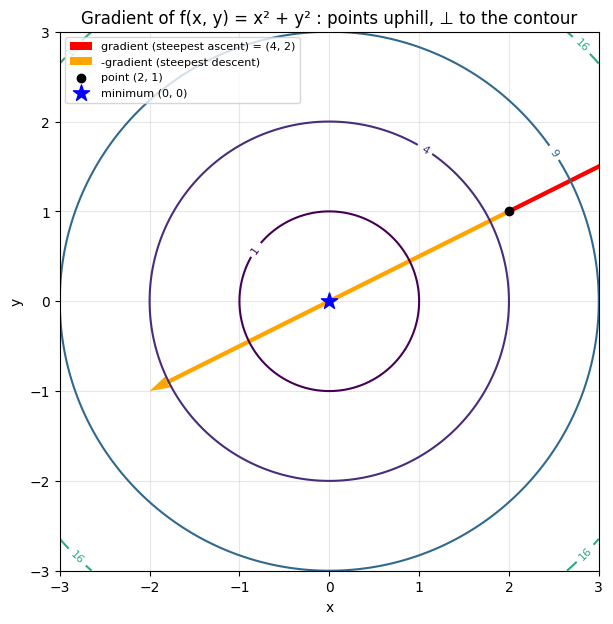

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# f(x, y) = x^2 + y^2 : a bowl.  Gradient = (2x, 2y)
f = lambda x, y: x**2 + y**2

# grid for the contour map
xs = np.linspace(-3, 3, 400)
ys = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(7, 7))
contours = ax.contour(X, Y, Z, levels=[1, 4, 9, 16, 25], cmap="viridis")
ax.clabel(contours, inline=True, fontsize=8)

# pick a point and draw its gradient (steepest ascent) + its negative (descent)
px, py = 2.0, 1.0
gx, gy = 2*px, 2*py            # gradient = (2x, 2y) = (4, 2)

ax.quiver(px, py, gx, gy, angles="xy", scale_units="xy", scale=1,
          color="red", width=0.008, label=f"gradient (steepest ascent) = ({gx:.0f}, {gy:.0f})")
ax.quiver(px, py, -gx, -gy, angles="xy", scale_units="xy", scale=1,
          color="orange", width=0.008, label="-gradient (steepest descent)")
ax.scatter([px], [py], color="black", zorder=5, label=f"point ({px:.0f}, {py:.0f})")
ax.scatter([0], [0], color="blue", marker="*", s=150, zorder=5, label="minimum (0, 0)")

ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Gradient of f(x, y) = x² + y² : points uphill, ⊥ to the contour")
ax.set_aspect("equal"); ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

## Application of gradient of the loss, and why −∇L is the descent direction

(No code — this is the reasoning that turns Day 1's partials into the descent step.)

Yesterday, for the two-parameter model $\hat{y} = wx + b$ with loss
$L(w, b) = (wx + b - y)^2$, we found the two partials:

$$\frac{\partial L}{\partial w} = 2x(\hat{y} - y), \qquad \frac{\partial L}{\partial b} = 2(\hat{y} - y)$$

### Bundle them into the gradient

The **gradient** of the loss is just those partials stacked into one vector — one
component per parameter:

$$\nabla L = \left( \frac{\partial L}{\partial w},\ \frac{\partial L}{\partial b} \right)
           = \big( 2x(\hat{y} - y),\ \ 2(\hat{y} - y) \big)$$

This vector lives in **parameter space** (axes: $w$ and $b$), not data space. It
points in the direction that increases the loss fastest.

### Why we step in the *negative* gradient

- $\nabla L$ points toward steepest **increase** of the loss.
- So $-\nabla L$ points toward steepest **decrease** — the fastest way to shrink
  the loss from where the parameters currently sit.

To train, step *both* parameters at once, opposite the gradient:

$$\begin{pmatrix} w \\ b \end{pmatrix}_{\text{new}}
= \begin{pmatrix} w \\ b \end{pmatrix}_{\text{old}}
- \alpha \, \nabla L
= \begin{pmatrix} w \\ b \end{pmatrix}_{\text{old}}
- \alpha \begin{pmatrix} 2x(\hat{y} - y) \\ 2(\hat{y} - y) \end{pmatrix}$$

where $\alpha$ (learning rate) sets the step size.

### What the vector's magnitude does

The gradient carries **direction *and* magnitude**. Its length $\|\nabla L\|$ is how
steep the loss is, so the step self-regulates:

- far from the minimum → steep → long gradient → big step;
- near the minimum → flat → short gradient → small step;
- at the minimum → $\nabla L = (0, 0)$ → no step → converged.

### The throughline

This is the single update that trains linear regression. Day 1 gave the partials;
today they became a gradient; **Day 4 (gradient descent) runs this update in a loop**
until the gradient hits zero — and the capstone applies it to a real weight + bias
model.

## Self-check — Day 2 (The Gradient)

Answer each out loud before opening the answers.

**Q1.** What is the gradient of a function, and how do you build it from partials?

**Q2.** The gradient has two properties: direction and magnitude. What does each
one tell you?

**Q3.** For $f(x, y) = x^2 + y^2$, write $\nabla f$, then evaluate it at $(1, 1)$.
In which direction does that arrow point relative to the bowl's minimum?

**Q4.** Why do we step in the direction of $-\nabla L$ (not $+\nabla L$) when training?

**Q5.** At the minimum of a bowl, what is the gradient vector, and what does that
make gradient descent do?

**Q6.** For the two-parameter loss, $\nabla L = \big(2x(\hat{y}-y),\ 2(\hat{y}-y)\big)$.
Why does the first component carry a factor of $x$ but the second doesn't?

---

<details>
<summary>Answers</summary>

**A1.** The gradient is a vector of all the function's partial derivatives — one
component per input: $\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$.
You build it by computing each partial (freeze the others, differentiate) and
stacking them.

**A2.** **Direction** = the way of steepest *increase* (most uphill).
**Magnitude** (length) = how steep that slope is — large means the function
changes fast there, zero means flat.

**A3.** $\nabla f = (2x, 2y)$; at $(1,1)$ it's $(2, 2)$. That arrow points *away*
from the minimum at the origin — the steepest-ascent direction. Its negative
$(-2,-2)$ points back toward the minimum.

**A4.** $\nabla L$ points toward steepest *increase* of the loss, so its negative
points toward steepest *decrease*. To minimize the loss we move opposite the
gradient: $\theta_{\text{new}} = \theta_{\text{old}} - \alpha \nabla L$.

**A5.** The gradient is the **zero vector** $(0,0)$ — no downhill direction
exists, so the update changes nothing and descent stops (converged). On a bowl
that's the true minimum.

**A6.** In the model $\hat{y} = wx + b$, the weight $w$ is multiplied by $x$, so
its effect on the loss is scaled by $x$ (that factor carries into its partial).
The bias $b$ is added directly, so its partial is just the raw error.

</details>